# Exercise 1

Estimate the following linear model $y = Xw + b + \epsilon$, where $X \in \mathbb{R}^{2000 \times 3}$ consists of 2000 examples, each consisting of 3 features sampled from a standard normal distribution and $\epsilon$ obeys a normal distribution with mean 0 and standard deviation of 0.1. The true weights of the model will be $w = [0.15, -0.2, 0.1]^T$ and $b = 0.2$. Create the linear regression model (**do not use PyTorch's predefined layers**) and train it as follows:

- set the weights and bias to 3;
- set the batch size to 20;
- **implement the mean squared error loss**;
- **implement the mini-batch gradient descent optimizer**, $lr = 0.02$ (do not use the torch.optim package);
- set the total number of epochs to 40.
  After the model is trained, compare the learned model parameters with the actual parameters.


In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [188]:
def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.1, y.shape)
    return X, y.reshape(-1, 1)

In [189]:
true_w = torch.tensor([0.15, -0.2, 0.1])
true_b = 0.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [190]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # The examples are read at random, in no particular order
    np.random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i : min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [191]:
batch_size = 20

for X, y in data_iter(batch_size, features, labels):
    print(X, "\n", y)
    break

tensor([[ 1.1373e+00,  2.1926e-01,  4.1337e-01],
        [-5.5447e-02,  6.4874e-01, -1.5245e+00],
        [-8.5527e-01, -1.5335e+00,  1.2889e-01],
        [-5.8763e-01, -3.4518e-01, -7.2878e-01],
        [-1.4679e+00, -1.7168e+00, -5.5025e-01],
        [ 7.2376e-01, -1.8847e-01, -5.8210e-01],
        [-1.1419e+00, -8.2924e-01,  1.3149e+00],
        [-7.8117e-01,  6.8727e-01,  7.8359e-01],
        [-3.4737e-01, -4.9671e-01, -1.3010e+00],
        [ 9.4461e-01, -1.5824e+00,  9.8713e-01],
        [-1.6328e+00, -3.2575e-01,  2.1100e+00],
        [-5.7266e-01,  8.3568e-02,  3.9991e-01],
        [-6.1595e-01, -1.0195e+00,  3.8482e-01],
        [ 2.5705e-01, -1.0626e+00, -6.3258e-01],
        [ 1.2097e+00,  8.7672e-01,  1.8313e+00],
        [ 1.4244e+00,  2.2692e+00,  1.3105e+00],
        [-2.8155e-01,  5.2819e-02,  4.2498e-01],
        [ 8.4365e-01,  1.9249e+00, -3.4053e-01],
        [-9.3313e-04, -1.0838e-01,  4.7941e-01],
        [ 1.4557e+00, -3.4610e-01, -2.6338e-01]]) 
 tensor([[ 0.4577]

In [192]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [193]:
batch_size = 20
data_iter = load_array((features, labels), batch_size)

In [194]:
# `nn` is an abbreviation for neural networks
from torch import nn

net = nn.Sequential(nn.Linear(3, 1))

In [195]:
w = torch.tensor([3.0, 3.0, 3.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)

In [196]:
def MSELoss(y, y_pred):
    return torch.mean((y - y_pred) ** 2)

In [197]:
num_epochs = 40
learning_rate = 0.02

for epoch in range(num_epochs):
    for X, y in data_iter:
        y_pred = (X @ w + b).reshape(-1, 1)
        l = MSELoss(y_pred, y)
        l.backward()

        with torch.no_grad():
            w -= learning_rate * w.grad
            b -= learning_rate * b.grad

        w.grad.data.zero_()
        b.grad.data.zero_()

    with torch.no_grad():
        y_pred_full = (features @ w + b).reshape(-1, 1)
        l = MSELoss(y_pred_full, labels)
    print(f"Epoch {epoch + 1}, Loss {l:f}")

Epoch 1, Loss 0.421258
Epoch 2, Loss 0.015646
Epoch 3, Loss 0.009513
Epoch 4, Loss 0.009463
Epoch 5, Loss 0.009471
Epoch 6, Loss 0.009465
Epoch 7, Loss 0.009475
Epoch 8, Loss 0.009460
Epoch 9, Loss 0.009464
Epoch 10, Loss 0.009463
Epoch 11, Loss 0.009465
Epoch 12, Loss 0.009473
Epoch 13, Loss 0.009467
Epoch 14, Loss 0.009474
Epoch 15, Loss 0.009478
Epoch 16, Loss 0.009478
Epoch 17, Loss 0.009466
Epoch 18, Loss 0.009480
Epoch 19, Loss 0.009468
Epoch 20, Loss 0.009482
Epoch 21, Loss 0.009461
Epoch 22, Loss 0.009468
Epoch 23, Loss 0.009468
Epoch 24, Loss 0.009459
Epoch 25, Loss 0.009465
Epoch 26, Loss 0.009462
Epoch 27, Loss 0.009480
Epoch 28, Loss 0.009464
Epoch 29, Loss 0.009462
Epoch 30, Loss 0.009465
Epoch 31, Loss 0.009462
Epoch 32, Loss 0.009469
Epoch 33, Loss 0.009459
Epoch 34, Loss 0.009464
Epoch 35, Loss 0.009466
Epoch 36, Loss 0.009459
Epoch 37, Loss 0.009464
Epoch 38, Loss 0.009466
Epoch 39, Loss 0.009463
Epoch 40, Loss 0.009457


In [198]:
w = net[0].weight.data
b = net[0].bias.data
print(f"Real parameters: w = {true_w}, b = {true_b}")
print(f"Learned parameters: w = {w}, b = {b}")

Real parameters: w = tensor([ 0.1500, -0.2000,  0.1000]), b = 0.2
Learned parameters: w = tensor([[ 0.4848, -0.4334, -0.1647]]), b = tensor([0.1349])


# Exercise 2

Implement the softmax regression model to classify images. Use the Imagenette dataset, which has 10 classes.

**Data Acquisition:** Download the Imagenette train images.

**Data Splitting:** Split the downloaded train images as follows:

- Validation set: 4456 images.
- Training set: 4456 images.
- Testing dataset: The remaining images from the original train set.

**Batch Size:** Set the batch size to 100.

**Image Resolution:** Resize the images to a resolution of (300, 100).

**Weight Initialization:** Initialize the model's weights randomly with:

- Zero mean.
- Standard deviation of 0.01.

**Loss Function:** Use the cross-entropy loss function.

**Optimization Algorithm:** Use mini-batch gradient descent as the optimization algorithm.

**Learning Rate:** Set the learning rate for the optimizer to 0.1.

**Number of Epochs:** Set the number of epochs for training to 5.

**Evaluation:** Evaluate the trained model on the test set.


In [7]:
import torch
import torchvision
from torch import nn
from torchvision.datasets import Imagenette
from torchvision import transforms


def load_data_imagenette(batch_size, resize=None):
    """Download the Imagenette dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    # Load all training images (Imagenette doesn't have train/test split parameter)
    imagenette_full = torchvision.datasets.Imagenette(
        root="../data", transform=trans, download=True
    )
    # Calculate sizes: train=4456, val=4456, test=remaining
    total_size = len(imagenette_full)
    train_size = 4456
    val_size = 4456
    test_size = total_size - train_size - val_size
    # Split the dataset into train, val, and test
    imagenette_train, imagenette_val, imagenette_test = torch.utils.data.random_split(
        imagenette_full,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42),
    )
    return (
        torch.utils.data.DataLoader(
            imagenette_train, batch_size, shuffle=True, num_workers=2
        ),
        torch.utils.data.DataLoader(
            imagenette_val, batch_size, shuffle=False, num_workers=2
        ),
        torch.utils.data.DataLoader(
            imagenette_test, batch_size, shuffle=False, num_workers=2
        ),
    )


train_iter, val_iter, test_iter = load_data_imagenette(100, resize=(300, 100))
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

torch.Size([100, 3, 300, 100]) torch.float32 torch.Size([100]) torch.int64


In [8]:
net = nn.Sequential(nn.Flatten(), nn.Linear(3 * 300 * 100, 10))

In [9]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01, mean=0)


net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=90000, out_features=10, bias=True)
)

In [10]:
lr = 0.1
optimizer = torch.optim.SGD(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss()

In [11]:
def evaluate_accuracy(net, data_iter):
    net.eval()
    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples * 100

In [12]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples * 100

In [13]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(
            f"Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}"
        )

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [14]:
num_epochs = 5
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(
    net, train_iter, val_iter, loss, num_epochs, optimizer
)

/var/folders/14/2swb_m_965n1mt5_3k_btqt00000gn/T/ipykernel_28823/3204225458.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 563.45, Train accuracy 13.82, Validation loss 315.66, Validation accuracy 18.16
Epoch 2, Train loss 399.13, Train accuracy 18.22, Validation loss 514.64, Validation accuracy 17.57
Epoch 3, Train loss 377.29, Train accuracy 19.97, Validation loss 375.51, Validation accuracy 16.09
Epoch 4, Train loss 294.09, Train accuracy 22.98, Validation loss 327.60, Validation accuracy 13.58
Epoch 5, Train loss 319.12, Train accuracy 22.71, Validation loss 254.79, Validation accuracy 22.64


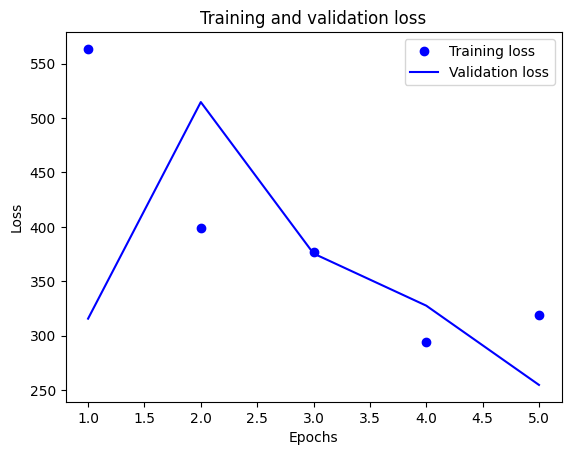

In [17]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, "bo", label="Training loss")
    plt.plot(epochs, val_loss_all, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


plot_loss(train_loss_all, val_loss_all)

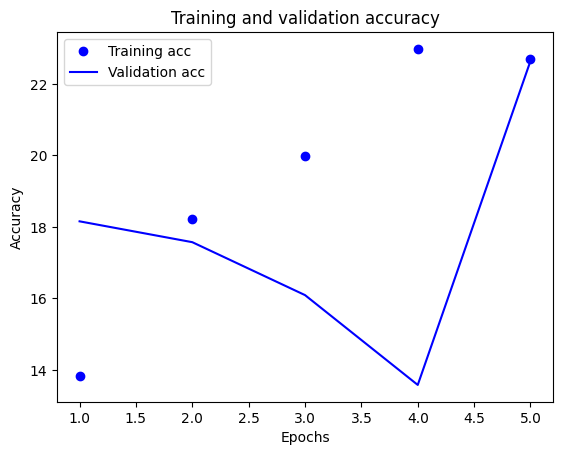

In [18]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, "bo", label="Training acc")
    plt.plot(epochs, val_acc_all, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_accuracy(train_acc_all, val_acc_all)

In [19]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f"Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}")

Test loss 257.06, Test accuracy 25.67


In [20]:
def get_imagenette_labels(labels):
    text_labels = [
        "tench",
        "English springer",
        "cassette player",
        "chain saw",
        "church",
        "French horn",
        "garbage truck",
        "gas pump",
        "golf ball",
        "parachute",
    ]
    return [text_labels[int(i)] for i in labels]

In [21]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

TypeError: Invalid shape (3, 300, 100) for image data

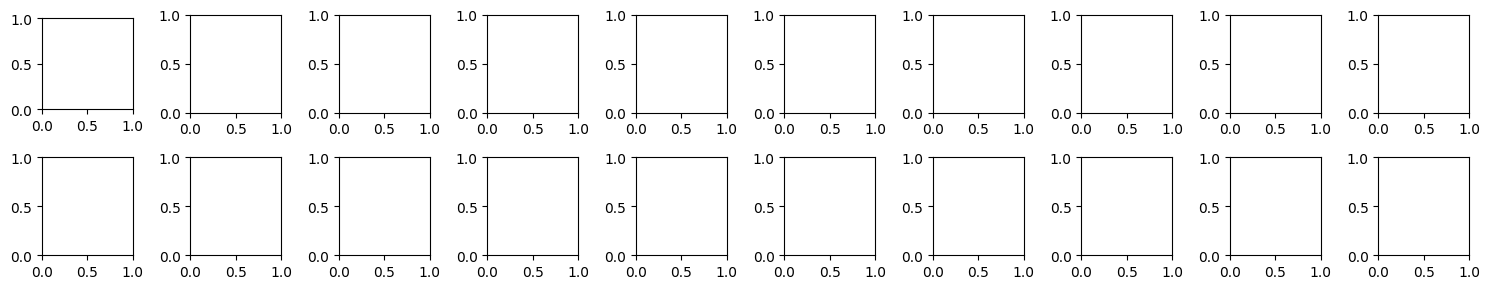

In [23]:
def predict(net, test_iter, n=20):
    for X, y in test_iter:
        break

    trues = get_imagenette_labels(y)
    preds = get_imagenette_labels(net(X).argmax(axis=1))
    titles = [true + "\n" + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 3, 300, 100)), 2, int(n / 2), titles=titles[0:n])


predict(net, test_iter)

# Exercise 3

Classify the Imagenette dataset (10 classes) using an MLP.

**Data Acquisition and Preparation:**

- **Download:** Download the Imagenette train images.
- **Split Train Images:** Split the downloaded train images as follows:
  - Validation set: 5000 images.
  - Training set: 4000 images.
  - Testing dataset: The remaining images from the original train set will represent the testing dataset.
- **Batch Size:** Set the batch size to 150.

**MLP Architecture:**

- The MLP consists of five hidden layers.
- Each hidden layer has 128 units.
- The activation function used is the rectified linear unit (ReLU).
- A dropout layer should be added after the third hidden layer.
- The dropout probability for this layer is 35%.

**Model Initialization:**

- **Weights:** Set the weights from a normal distribution with a standard deviation (`std`) of 0.01.
- **Biases:** Set the biases to 0.

**Training Parameters:**

- **Learning Rate:** Set the learning rate to 0.15.
- **Epochs:** Train the model for 15 epochs.

**Evaluation:**

- Evaluate the trained model on the test set.


In [24]:
import torchvision
from torchvision.datasets import Imagenette
from torchvision import transforms


def load_data_imagenette(batch_size, resize=None):
    """Download the Imagenette dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    # Load all training images (Imagenette doesn't have train/test split parameter)
    imagenette_full = torchvision.datasets.Imagenette(
        root="../data", transform=trans, download=True
    )
    # Calculate sizes: train=4456, val=4456, test=remaining
    total_size = len(imagenette_full)
    train_size = 4000
    val_size = 5000
    test_size = total_size - train_size - val_size
    # Split the dataset into train, val, and test
    imagenette_train, imagenette_val, imagenette_test = torch.utils.data.random_split(
        imagenette_full,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42),
    )
    return (
        torch.utils.data.DataLoader(
            imagenette_train, batch_size, shuffle=True, num_workers=2
        ),
        torch.utils.data.DataLoader(
            imagenette_val, batch_size, shuffle=False, num_workers=2
        ),
        torch.utils.data.DataLoader(
            imagenette_test, batch_size, shuffle=False, num_workers=2
        ),
    )


train_iter, val_iter, test_iter = load_data_imagenette(150, resize=(300, 100))
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

torch.Size([150, 3, 300, 100]) torch.float32 torch.Size([150]) torch.int64


In [25]:
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 300 * 100, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(0.35),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

In [26]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01, mean=0)


net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=90000, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=128, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.35, inplace=False)
  (8): Linear(in_features=128, out_features=128, bias=True)
  (9): ReLU()
  (10): Linear(in_features=128, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [27]:
lr = 0.15
optimizer = torch.optim.SGD(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss()

In [28]:
def evaluate_accuracy(net, data_iter):
    net.eval()
    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples * 100

In [29]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples * 100

In [30]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(
            f"Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}"
        )

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [31]:
num_epochs = 15
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(
    net, train_iter, val_iter, loss, num_epochs, optimizer
)

Epoch 1, Train loss 2.30, Train accuracy 9.50, Validation loss 2.30, Validation accuracy 9.86
Epoch 2, Train loss 2.30, Train accuracy 10.30, Validation loss 2.30, Validation accuracy 9.86
Epoch 3, Train loss 2.30, Train accuracy 10.38, Validation loss 2.30, Validation accuracy 9.86
Epoch 4, Train loss 2.30, Train accuracy 10.30, Validation loss 2.30, Validation accuracy 9.70
Epoch 5, Train loss 2.30, Train accuracy 10.57, Validation loss 2.30, Validation accuracy 9.70
Epoch 6, Train loss 2.30, Train accuracy 10.67, Validation loss 2.30, Validation accuracy 9.70
Epoch 7, Train loss 2.30, Train accuracy 10.53, Validation loss 2.30, Validation accuracy 9.70
Epoch 8, Train loss 2.30, Train accuracy 10.27, Validation loss 2.30, Validation accuracy 9.70
Epoch 9, Train loss 2.30, Train accuracy 10.82, Validation loss 2.30, Validation accuracy 9.70
Epoch 10, Train loss 2.30, Train accuracy 10.90, Validation loss 2.30, Validation accuracy 9.86
Epoch 11, Train loss 2.30, Train accuracy 10.40, V

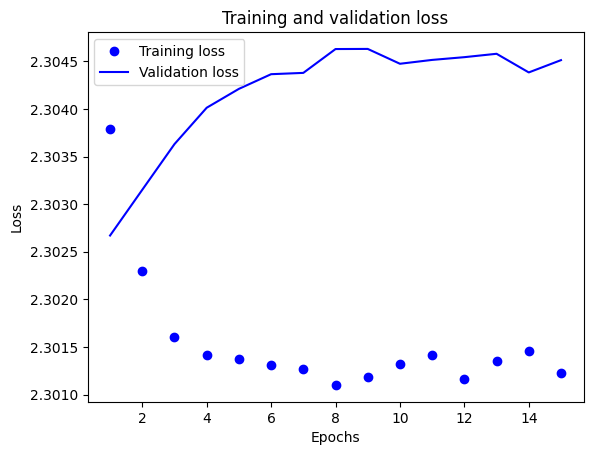

In [32]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, "bo", label="Training loss")
    plt.plot(epochs, val_loss_all, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


plot_loss(train_loss_all, val_loss_all)

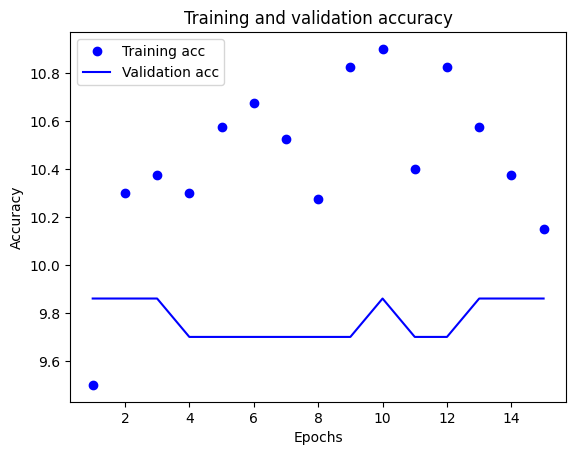

In [33]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, "bo", label="Training acc")
    plt.plot(epochs, val_acc_all, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_accuracy(train_acc_all, val_acc_all)

In [34]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f"Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}")

Test loss 2.31, Test accuracy 8.10


# Exercise 4

Apply a linear regression model on the "Wine Quality (red)" dataset.

**Dataset Details:**

- **Name:** Wine Quality (red) dataset
- **Size:** Contains 1599 examples
- **Features:** Each example has 11 numerical features describing various properties of red wines
- **Target:** A target quality score, which is an integer between 3 and 8
- **Preprocessing:**
  - All input features must be standardized by subtracting the mean and dividing by the standard deviation of each feature
  - The mean and standard deviation should be computed _only_ on the training set
- **Splitting:** The dataset needs to be split into:
  - A training set (80% of the data)
  - A testing set (20% of the data)

**Dataset Loading:**

```python
from sklearn.datasets import fetch_openml

data = fetch_openml(name="wine-quality-red", version=1, as_frame=True)
df = data.frame

X = df.drop("class", axis=1).values
y = df["class"].astype(np.float32).values
```

- `X` will contain the input features
- `y` will contain the target quality scores
- The target column is named "class"

**Linear Regression Model Creation and Training (Manual Implementation):**
The model must be created and trained **without using PyTorch's predefined layers** or the `torch.optim` package.
The training process should follow these steps:

- **Weights and Bias Initialization:** Initialize all model weights and the bias term to 0
- **Batch Size:** Set the batch size to 32
- **Loss Function:** Implement the Mean Squared Error (MSE) loss manually
- **Optimizer:** Implement the mini-batch gradient descent optimizer manually, with a learning rate (`lr`) of 0.01 (do not use `torch.optim`)
- **Epochs:** Set the total number of epochs to 40
- **Training Loop:** Train the model on the training set and record the training loss after each epoch

**Post-Training Evaluation:**
After the training is completed, the following evaluations are required:

- **Loss Curve Plot:** Plot the recorded training loss curve across all epochs
- **Test Set Evaluation:** Evaluate the trained model on the test set
- **Metrics:** Compute and report the Mean Squared Error (MSE) and Mean Absolute Error (MAE) on the test set


In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import torch

torch.manual_seed(42)
np.random.seed(42)

data = fetch_openml(name="wine-quality-red", version=1, as_frame=True)
df = data.frame

X = df.drop("class", axis=1).values
y = df["class"].astype(np.float32).values

# Exercise 5

Use the Oxford-IIIT Pet dataset.

**Dataset:**

- **Source:** Oxford-IIIT Pet dataset from `torchvision.datasets`
- **Content:** Contains 7,349 images of different cat and dog breeds
- **Labels:** Each image has a class label in the range `[0, 36]`
- **Splits:** Divided into two official subsets: `trainval` (training + validation data) and `test`

**Preprocessing steps for all images:**

- **Resizing:** Resize each image to a fixed resolution of `64 × 64` pixels
- **Tensor Conversion:** Convert each image to a PyTorch tensor with pixel values in the interval `[0, 1]`

**Dataset Splitting:**

- Use the entire `trainval` split to create a training set and a validation set by performing an `80% / 20%` random split
- Use the separate official `test` split as the final test set

**Multilayer Perceptron (MLP) Classifier Construction (using PyTorch):**

- **Hidden Layers:** 2 hidden layers
  - First layer: 512 hidden units
  - Second layer: 256 hidden units
  - Activation function: Rectified Linear Unit (ReLU) for both hidden layers
- **Dropout:** A dropout function after the first hidden layer with a dropout probability of `10%`

**Model Training Settings:**

- **Loss Function:** Use Cross-Entropy Loss
- **Optimizer:** Use the Adam optimizer with a learning rate (`lr`) of `0.001`
- **Batch Size:** Set the batch size to `64`
- **Epochs:** Train the model for `15` epochs
- **Recording per epoch:** After each epoch, compute and record:
  - Training loss
  - Training accuracy
  - Validation loss
  - Validation accuracy

**Post-Training Evaluation:**

- Plot both the training and validation loss curves
- Plot the training and validation accuracy curves
- Compute the test accuracy


# Exercise 6

Generate an artificial regression dataset and train a Multilayer Perceptron (MLP) model using PyTorch.

**1. Dataset Generation:**

- **Type:** Artificial regression dataset
- **Input Features:** 3 input features, denoted as `x = (x0, x1, x2)`
- **Input Distribution:** Each sample `x` is drawn independently from a uniform distribution on `[-2, 2]³`
- **Target Function:** The target value `y` is defined by the equation:
  `y = sin(x0) + 0.5 * x1² - x2 + ε`
  where `ε` (epsilon) represents Gaussian noise, distributed as `N(0, 0.1²)`

**2. Dataset Splitting:**

- **Total Samples:** Generate 10,000 samples
- **Splits:**
  - Training set: 70% of samples
  - Validation set: 15% of samples
  - Test set: 15% of samples

**3. MLP Regression Model Construction (using PyTorch):**

- **Architecture:** The MLP will consist of 3 hidden layers
- **Hidden Units:** Each of the 3 hidden layers will have 64 hidden units
- **Activation Function:** Rectified Linear Unit (ReLU) activation function for all hidden layers

**4. Model Training Settings:**

- **Loss Function:** Mean Squared Error (MSE)
- **Optimizer:** Adam optimizer
- **Learning Rate (`lr`):** 0.001
- **Batch Size:** 64
- **Number of Epochs:** 50

**5. Post-Training Evaluation:**

- **Plotting:**
  - Plot the training loss curve
  - Plot the validation loss curve
- **Metrics:**
  - Compute the Mean Squared Error (MSE) on the test set
  - Compute the Mean Absolute Error (MAE) on the test set
